In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import h5py
from scipy.fft import rfft, rfftfreq

In [176]:
from cycler import cycler
def load_plotting_setting():
    # colors=['#fe9f6d', '#de4968', '#8c2981', '#3b0f70', '#000004']
    # colors = plt.colormaps.get_cmap('tab20b').resampled(6).colors
    cmap = plt.colormaps.get_cmap('viridis')
    colors = cmap(np.linspace(0, 0.95, 5))

    default_cycler = cycler(color=colors)
    
    params = {'figure.figsize': (7, 5),
              'axes.prop_cycle': default_cycler,
              'axes.titlesize': 14,
              'legend.fontsize': 12,
              'axes.labelsize': 14,
              'axes.titlesize': 14,
              'xtick.labelsize': 12,
              'ytick.labelsize': 12,
              'xtick.direction': 'in',
              'ytick.direction': 'in',
              'xtick.top': True,
              'ytick.right': True
              }
    plt.rcParams.update(params)

load_plotting_setting()

In [159]:
file_name = r"E:\lorentz_force\sphere_20250708\20250802_2e-8mbar\20250802_m350e_79khz_100vpp_withb_925.hdf5"
f = h5py.File(file_name, 'r')

dd = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv']/1000
gg = f['data']['channel_g'][:] * f['data']['channel_g'].attrs['adc2mv']/1000

print(f['data'].attrs['pressure_mbar'])
print(f['data'].attrs['drive_info'])
print(f['data'].attrs['channel_a_mean_mv'])
print(f['data'].attrs['channel_b_mean_mv'])
print(f['data'].attrs['channel_c_mean_mv'])

f.close()

1.7e-08
1.81,10.50,19.005

-2582.3141455325986
-2092.0929152297535
-1338.022532629373


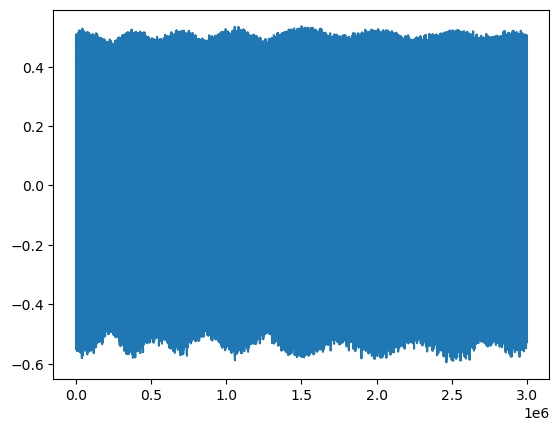

In [110]:
plt.plot(dd)
# plt.plot(gg)

In [160]:
nfile = 300
amps_wb, amps_nob = np.empty(nfile), np.empty(nfile)
maxd_wb, maxd_nob = np.empty(nfile), np.empty(nfile)

for i in range(nfile):
    if i % 100 == 0:
        print(i)
    file_name = rf"E:\lorentz_force\sphere_20250708\20250802_2e-8mbar\20250802_m350e_79khz_100vpp_withb_{i}.hdf5"
    f = h5py.File(file_name, 'r')
    dd = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv']/1000
    gg = f['data']['channel_g'][:] * f['data']['channel_g'].attrs['adc2mv']/1000
    f.close()

    file_name_nob = rf"E:\lorentz_force\sphere_20250708\20250802_2e-8mbar\20250802_m350e_79khz_100vpp_nob_{i}.hdf5"
    f = h5py.File(file_name_nob, 'r')
    dd_nob = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv']/1000
    gg_nob = f['data']['channel_g'][:] * f['data']['channel_g'].attrs['adc2mv']/1000
    f.close()

    idx_freq = np.argmax(rfft(gg))
    amps_wb[i] = np.imag(rfft(dd) / rfft(gg))[idx_freq]
    amps_nob[i] = np.imag(rfft(dd_nob) / rfft(gg_nob))[idx_freq]
    

0
100
200
300
400
500
600
700
800
900


0.00021006291143615903
-5.275516390359405e-06


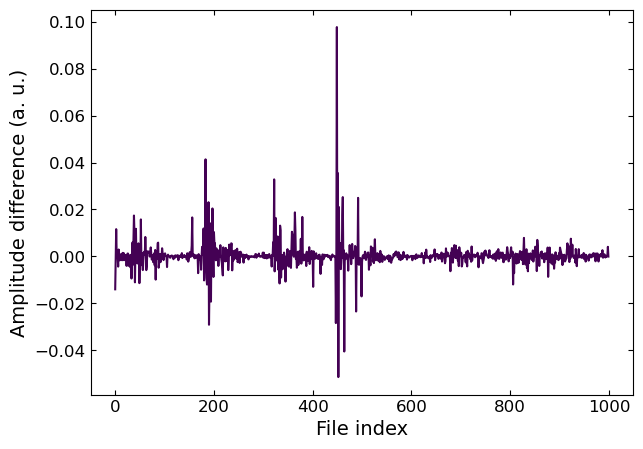

In [177]:
diff = amps_wb - amps_nob

plt.plot(diff)
# plt.ylim(-0.005, 0.005)

plt.xlabel('File index')
plt.ylabel('Amplitude difference (a. u.)')

print(np.mean(diff))
print(np.mean(diff[np.abs(diff) < 0.01]))

In [165]:
np.median(amps_wb[550:]) - np.median(amps_nob[550:])

np.float64(8.942989748689234e-05)

(0.0, 0.025)

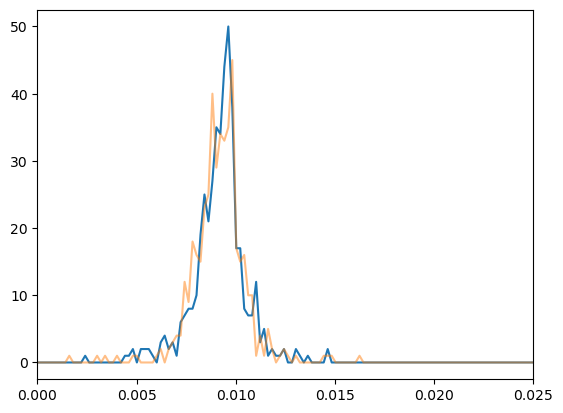

In [172]:
be = np.linspace(-0.05, 0.05, 500)
bc = 0.5 * (be[1:] + be[:-1])

hh, _ = np.histogram(amps_wb[550:], bins=be)
hh_nob, _ = np.histogram(amps_nob[550:], bins=be)

plt.plot(bc, hh)
plt.plot(bc, hh_nob, alpha=0.5)

# plt.yscale('log')

# plt.vlines(x=0, ymin=1e-5, ymax=250, color='r')
# plt.ylim(1e-1, 250)
plt.xlim(0, 0.025)

In [111]:
freq[np.argmax(rfft(gg))]

np.float64(79000.66666666666)

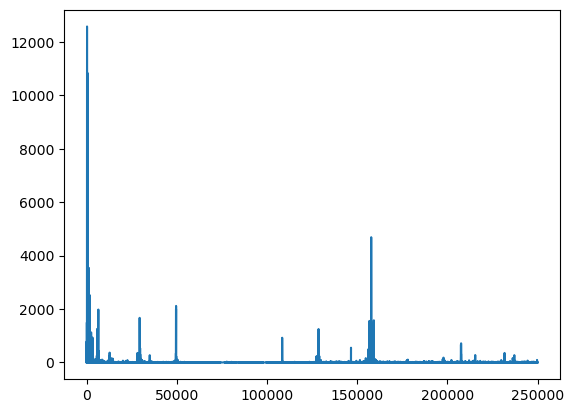

In [108]:
freq = rfftfreq(n=dd.size, d=2e-6)

plt.plot(freq, np.abs(rfft(dd) / rfft(gg)))
# plt.xlim(78500, 79500)
# plt.ylim(0, 10)

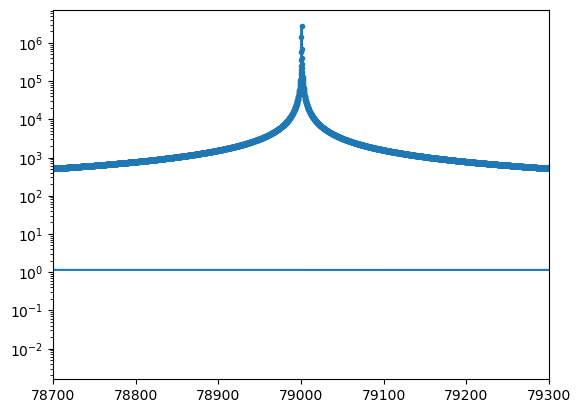

In [105]:
plt.plot(freq, np.abs(fft(gg)), '.-')
plt.xlim(78700, 79300)
plt.yscale('log')

(78000.0, 80000.0)

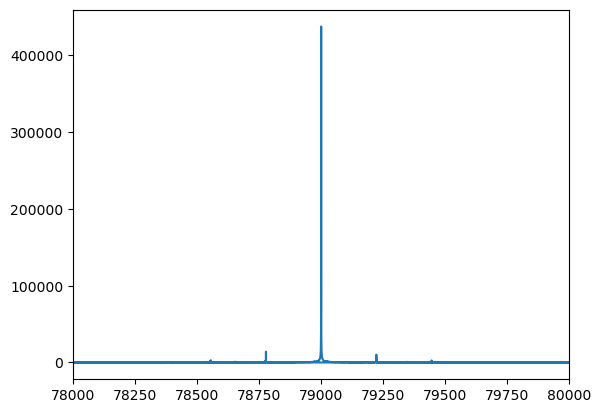

In [87]:
plt.plot(freq, np.abs(fft(dd)))
plt.xlim(78000, 80000)
# plt.yscale('log')